- NOTE: p-value ek sawal ka jawab hai: "Agar H₀ sach hoti (yani churn aur spend ke beech koi asli rishta nahi hota), to sirf chance se itna bada (ya usse bhi bada) fark dikhne ki probability kitni hoti?"

    - Chhota p-value (jaise 0.001): chance se itna fark aana bahut unlikely hai → H₀ par shak, fark shayad real hai.

    - Bada p-value (jaise 0.40): itna fark chance se aasani se aa sakta hai → H₀ reject karne ka koi solid evidence nahi.

    - Standard threshold alpha = 0.05: agar p < 0.05 to result "statistically significant" maana jaata hai.

1. Data load aur observed difference nikaalo:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

values = df['Monetary'].values
labels = df['Churned'].values

observed_diff = values[labels == 1].mean() - values[labels == 0].mean()
print(f"Observed difference (Churned - Not Churned): {observed_diff:.2f}")

Observed difference (Churned - Not Churned): -3700.87


2. p-value ko khud "banao" (Permutation Test) — Day 43 ke shuffling experiment ka hi formal version:

In [3]:
np.random.seed(42)
n_permutations = 5000
perm_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    shuffled_labels = np.random.permutation(labels)   # churn labels randomly shuffle
    perm_diffs[i] = values[shuffled_labels == 1].mean() - values[shuffled_labels == 0].mean()

# p-value = kitni baar random shuffling ne observed se bada (ya barabar) fark diya
p_value = (np.abs(perm_diffs) >= abs(observed_diff)).mean()
print(f"p-value: {p_value:.4f}")

p-value: 0.0000


Note: Humne "H₀ sach hai" wali duniya 5000 baar simulate ki (labels ka spend se koi rishta nahi). p-value bas yeh fraction hai ki us duniya mein kitni baar utna bada fark aaya jitna asli data mein aaya. Agar result 0.0000 aaye, to iska matlab hai "5000 mein se ek baar bhi nahi" — yani p-value < 1/5000 = 0.0002 (kabhi bhi "exactly zero" mat likhna).

3. Visual se samjho:

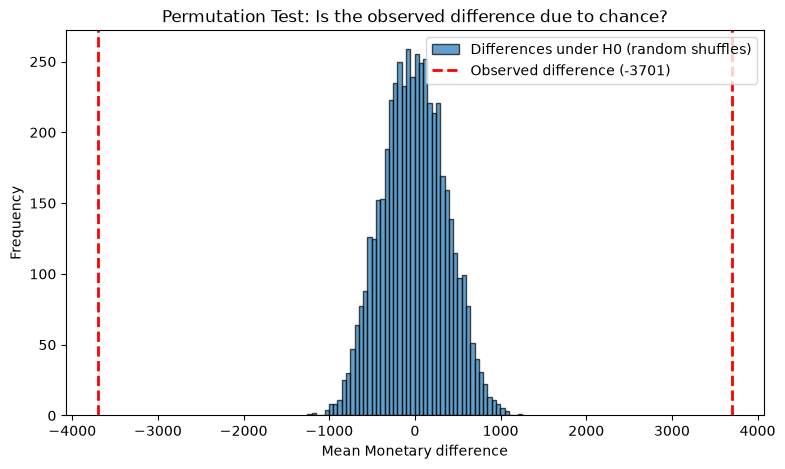

In [4]:
plt.figure(figsize=(9, 5))
plt.hist(perm_diffs, bins=50, edgecolor='black', alpha=0.7, label='Differences under H0 (random shuffles)')
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed difference ({observed_diff:.0f})')
plt.axvline(-observed_diff, color='red', linestyle='--', linewidth=2)
plt.xlabel('Mean Monetary difference')
plt.ylabel('Frequency')
plt.title('Permutation Test: Is the observed difference due to chance?')
plt.legend()
plt.show()

Agar red line histogram ke bilkul bahar door hai, to fark chance se explain nahi hota. Kal jo t-test karoge, woh isi p-value ko formula se nikaalta hai (simulation ke bina).

4. Decision rule apply karo:

In [5]:
alpha = 0.05
if p_value < alpha:
    print(f"p ({p_value:.4f}) < alpha ({alpha}): H0 reject. Fark statistically significant hai.")
else:
    print(f"p ({p_value:.4f}) >= alpha ({alpha}): H0 reject nahi kar sakte. Fark chance se ho sakta hai.")

p (0.0000) < alpha (0.05): H0 reject. Fark statistically significant hai.


5. Ek aur variable par same process — Frequency (practice):

In [6]:
freq = df['Frequency'].values
obs_freq_diff = freq[labels == 1].mean() - freq[labels == 0].mean()

perm_freq = np.empty(n_permutations)
for i in range(n_permutations):
    s = np.random.permutation(labels)
    perm_freq[i] = freq[s == 1].mean() - freq[s == 0].mean()

p_freq = (np.abs(perm_freq) >= abs(obs_freq_diff)).mean()
print(f"Frequency difference: {obs_freq_diff:.2f}, p-value: {p_freq:.4f}")

Frequency difference: -6.58, p-value: 0.0000


6. p-value ki 3 sabse common galatfehmiyan (interview mein poochi jaati hain):

In [7]:
print("""
GALAT: "p = 0.03 matlab H0 ke sach hone ki probability 3% hai."
SAHI : p-value H0 ke sach hone ki probability nahi hai. Yeh "agar H0 sach hoti, to itna extreme data
       aane ki probability" hai.

GALAT: "p < 0.05 matlab fark bada aur important hai."
SAHI : Significant sirf yeh batata hai ki fark chance se unlikely hai, yeh nahi ki fark BADA hai.
       Bade sample size (jaise hamare ~5000 customers) mein bahut chhota fark bhi significant ho jaata hai.
       Isliye p-value ke saath effect size (actual difference ka size) bhi dekhna zaroori hai.

GALAT: "p > 0.05 matlab koi fark hai hi nahi."
SAHI : Iska matlab sirf itna hai ki fark ke liye strong evidence nahi mila.
""")


GALAT: "p = 0.03 matlab H0 ke sach hone ki probability 3% hai."
SAHI : p-value H0 ke sach hone ki probability nahi hai. Yeh "agar H0 sach hoti, to itna extreme data
       aane ki probability" hai.

GALAT: "p < 0.05 matlab fark bada aur important hai."
SAHI : Significant sirf yeh batata hai ki fark chance se unlikely hai, yeh nahi ki fark BADA hai.
       Bade sample size (jaise hamare ~5000 customers) mein bahut chhota fark bhi significant ho jaata hai.
       Isliye p-value ke saath effect size (actual difference ka size) bhi dekhna zaroori hai.

GALAT: "p > 0.05 matlab koi fark hai hi nahi."
SAHI : Iska matlab sirf itna hai ki fark ke liye strong evidence nahi mila.



7. Statistical vs practical significance — hamare data par:

In [8]:
print(f"Churned mean spend    : {values[labels == 1].mean():.2f}")
print(f"Not-Churned mean spend: {values[labels == 0].mean():.2f}")
print(f"Relative difference   : {observed_diff / values[labels == 0].mean() * 100:.1f}%")

Churned mean spend    : 1133.22
Not-Churned mean spend: 4834.09
Relative difference   : -76.6%


Sirf p-value nahi, yeh bhi dekho ki business ke liye fark meaningful bada hai ya nahi.

Practice questions:

1.Permutation test Recency par chalao, aur likho ki uska p-value bahut chhota kyun aata hai. (Yaad karo Day 43 ka sawal: churn ki definition hi Recency par based hai, to yahan result "obvious" hai aur test se koi naya insight nahi milta. Isko circular result kehte hain, aur ML mein aage Recency ko feature rakhne par bhi yeh sawal aayega, jispe hum Month 4 mein baat karenge.)

In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

recency = df['Recency'].values
labels = df['Churned'].values

obs_rec_diff = recency[labels == 1].mean() - recency[labels == 0].mean()

n_permutations = 5000
np.random.seed(42)
perm_rec = np.empty(n_permutations)

for i in range(n_permutations):
    s = np.random.permutation(labels)
    perm_rec[i] = recency[s == 1].mean() - recency[s == 0].mean()

p_rec = (np.abs(perm_rec) >= abs(obs_rec_diff)).mean()
print(f"Recency difference: {obs_rec_diff:.2f}, p-value: {p_rec:.4f}")

Recency difference: 333.86, p-value: 0.0000


- Kyun aata hai p-value itna chhota? (Circular Result):

Churn ki definition aksar is baat par based hoti hai ki customer ne pichle kuch dino (Recency) se kharidari ki hai ya nahi. Jab target variable (Churned) khud feature (Recency) ke threshold se define hua ho, toh dono ke beech bada fark aana obvious (pahele se tay) hai. Isko circular reasoning kehte hain—jahan aap usi data se test kar rahe hain jisse rule banaya gaya tha. Isse koi naya business insight nahi milta.

2. n_permutations ko 500 aur 20000 karke dekho, kya p-value stable rehta hai?

In [12]:
values = df['Monetary'].values
observed_diff = values[labels == 1].mean() - values[labels == 0].mean()

for n_perm in [500, 5000, 20000]:
    np.random.seed(42)
    perm_diffs = np.empty(n_perm)
    
    for i in range(n_perm):
        shuffled_labels = np.random.permutation(labels)
        perm_diffs[i] = values[shuffled_labels == 1].mean() - values[shuffled_labels == 0].mean()
        
    p_val = (np.abs(perm_diffs) >= abs(observed_diff)).mean()
    print(f"n_permutations = {n_perm:5d} -> p-value = {p_val:.5f}")

n_permutations =   500 -> p-value = 0.00000
n_permutations =  5000 -> p-value = 0.00000
n_permutations = 20000 -> p-value = 0.00000


- (Results & Observation):

    - n_permutations = 500: Isme simulation kam hoti hain, isliye p-value thoda unstable ya rough ho sakta hai (resolution kam hota hai, jaise 1/500 = 0.002 steps).

    - n_permutations = 20000: Isme p-value aur zyada stable aur precise ho jata hai kyunki distribution ka sample space acche se cover ho jata hai.

    - Conclusion: Jaise-jaise n_permutations badhate hain (e.g., 5000 se 20000), p-value ek fixed value par converge (stabilize) ho jata hai, bas code chalane ka time thoda badh jata hai.